# 01d Traffic Event Trigger Candidate v2

01d v1의 가장 중요한 발견은 다음이다.

```text
red traffic HSV detector는 stop sign을 traffic red처럼 잡는다.
```

이건 버그라기보다 색 기반 detector의 자연스러운 한계다. stop sign도 빨간색 compact object이고, red traffic light도 빨간색 compact object다. 따라서 traffic event detector는 단순히 `red 색 + contour + 오른쪽`으로 끝나면 안 된다.

v2에서는 문제 정의를 다시 잡는다.

```text
목표:
  실제 주행 state machine에 넣을 수 있는 traffic event 후보를 정리한다.

핵심 변화:
  1. negative를 stop_sign_negative / final_redline_negative로 분리한다.
  2. green은 보수적으로 잡는다. green 오검출은 곧 "가도 된다" 오판이므로 위험하다.
  3. red는 traffic light 위치 ROI를 더 엄격하게 둔다.
  4. stop sign은 YOLO sign detector가 우선권을 가져야 한다는 runtime rule을 명시한다.
```

이 노트북도 최종 contract를 바로 확정하지 않는다. 다만 contract 직전 후보를 더 현실적으로 좁힌다.

## v1에서 바뀌는 판단 기준

v1에서는 `redline_negative`를 하나로 묶었다. 하지만 실제 파일명을 확인하니 다음처럼 나뉜다.

```text
stop_sign_negative: stop sign 이미지
final_redline_negative: final redline 이미지
```

이 둘은 의미가 다르다.

- stop sign이 red traffic으로 잡히는 것은 색 detector만으로는 막기 어렵다. 대신 YOLO sign event가 우선권을 가져야 한다.
- final redline이 red traffic으로 잡히는 것은 더 위험하다. traffic light가 아닌 바닥 선을 신호등으로 오판하는 것이기 때문이다.

따라서 summary도 아래처럼 따로 본다.

```text
target_hit_pct
cross_color_hit_pct
stop_sign_negative_hit_pct
final_redline_negative_hit_pct
```

In [1]:
from pathlib import Path
from IPython.display import display, Image
import json
import math
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(r'~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization')
EXP_ROOT = PROJECT_ROOT / '10_experiments' / '18_opencv_color_event_detector'
DATA_ROOT = PROJECT_ROOT / '20_shared_assets' / 'dataset'
TRAFFIC_ROOT = DATA_ROOT / 'traffic' / 'raw'
REDLINE_ROOT = DATA_ROOT / 'redline' / 'raw'

OUT_ROOT = EXP_ROOT / 'review_outputs' / '01d_traffic_event_trigger_candidate_v2'
TABLE_DIR = OUT_ROOT / 'tables'
OVERLAY_DIR = OUT_ROOT / 'overlays'
PLOT_DIR = OUT_ROOT / 'plots'
for p in [TABLE_DIR, OVERLAY_DIR, PLOT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('EXP_ROOT:', EXP_ROOT)
print('TRAFFIC_ROOT:', TRAFFIC_ROOT)
print('REDLINE_ROOT:', REDLINE_ROOT)
print('OUT_ROOT:', OUT_ROOT)

EXP_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector
TRAFFIC_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\dataset\traffic\raw
REDLINE_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\dataset\redline\raw
OUT_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01d_traffic_event_trigger_candidate_v2


## Windows long-path helper

이 프로젝트 경로는 길어서 `Path.exists()`나 OpenCV I/O가 간헐적으로 실패할 수 있다. 따라서 모든 이미지 I/O는 long-path helper를 거친다.

In [2]:
def fs_path(path):
    path = Path(path)
    s = str(path.resolve())
    if len(s) >= 240 and not s.startswith('\\\\?\\'):
        return '\\\\?\\' + s
    return s

def exists_fs(path):
    return Path(path).exists() or __import__('os').path.exists(fs_path(path))

def imread_bgr(path):
    img = cv2.imread(fs_path(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    return img

def imwrite(path, img):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    ok = cv2.imwrite(fs_path(path), img)
    if not ok:
        raise RuntimeError(f'cv2.imwrite failed: {path}')
    return path

def show_saved_image(path, width=None):
    path = Path(path)
    with open(fs_path(path), 'rb') as f:
        data = f.read()
    display(Image(data=data, width=width))

## 데이터 index: negative를 분리한다

`redline/raw` 폴더는 이름과 의미가 섞여 있다.

- 파일명에 `stop`이 들어가면 `stop_sign_negative`
- 파일명에 `redline`이 들어가면 `final_redline_negative`
- 나머지는 `other_negative`

이 분리가 v2의 핵심이다.

In [3]:
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

def iter_images(folder):
    folder = Path(folder)
    for p in sorted(folder.rglob('*')):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            yield p

def negative_role_from_name(name):
    low = name.lower()
    if 'stop' in low:
        return 'stop_sign_negative'
    if 'redline' in low or 'finish' in low:
        return 'final_redline_negative'
    return 'other_negative'

def build_index():
    rows=[]
    for label in ['green','red']:
        for p in iter_images(TRAFFIC_ROOT / label):
            rows.append({'kind':'traffic','label':label,'eval_base':'traffic_'+label,'negative_role':'none','path':str(p),'filename':p.name})
    for p in iter_images(REDLINE_ROOT):
        role=negative_role_from_name(p.name)
        rows.append({'kind':'negative','label':role,'eval_base':role,'negative_role':role,'path':str(p),'filename':p.name})
    return pd.DataFrame(rows)

index_df=build_index()
index_df.to_csv(TABLE_DIR/'traffic_event_v2_dataset_index.csv', index=False, encoding='utf-8-sig')
display(index_df.groupby(['kind','label']).size().reset_index(name='count'))

,kind,label,count
0,negative,final_redline_negative,101
1,negative,stop_sign_negative,233
2,traffic,green,313
3,traffic,red,343


## 후보 설계

v2에서는 후보 수를 의도적으로 줄인다. v1처럼 모든 조합을 크게 벌리면 해석이 흐려진다.

### 색 profile

- `green_balanced`: green은 보수적으로 간다. loose green은 v1에서 red/negative를 많이 잡았다.
- `red_balanced`: red는 너무 strict하면 실제 red traffic도 놓친다.
- `red_conservative`: red의 V/S를 조금 높여 stop/final redline 오검출이 줄어드는지 보는 비교 후보.

### contour profile

- `event_near`: 이벤트 후보로 적당한 크기.
- `event_close`: 더 가까운 경우만 통과. 늦을 수 있지만 false positive는 줄어들 수 있다.

### traffic ROI

- `green_slot`: 오른쪽 위쪽. green lens는 신호등 상단에 있다.
- `green_slot_strict`: green 오검출 방지용 더 엄격한 후보.
- `red_slot`: 오른쪽 중간. red lens는 green보다 아래쪽이다.
- `red_slot_strict_x`: stop sign false hit가 주로 x≈0.60에 몰렸으므로, red traffic은 x를 더 오른쪽으로 요구한다.

이 ROI는 final contract가 아니라 후보이다. 하지만 v1 결과상 red는 x 위치 조건이 특히 중요하다.

In [4]:
COLOR_PROFILES = {
    'green_balanced': {
        'target':'green', 'h_ranges':[(60,105)], 's_min':110, 'v_min':100,
        'description':'balanced green; avoids loose false positives',
    },
    'green_conservative': {
        'target':'green', 'h_ranges':[(65,100)], 's_min':130, 'v_min':115,
        'description':'more conservative green comparison',
    },
    'red_balanced': {
        'target':'red', 'h_ranges':[(0,12),(168,179)], 's_min':105, 'v_min':90,
        'description':'balanced red; keeps dim red traffic lights',
    },
    'red_conservative': {
        'target':'red', 'h_ranges':[(0,10),(170,179)], 's_min':135, 'v_min':120,
        'description':'more conservative red comparison',
    },
}

CONTOUR_PROFILES = {
    'event_near': {
        'green': {'min_area':1400, 'min_w':32, 'min_h':35, 'max_aspect':4.0, 'min_fill':0.045},
        'red':   {'min_area':180,  'min_w':13, 'min_h':15, 'max_aspect':5.0, 'min_fill':0.035},
        'description':'near event candidate',
    },
    'event_close': {
        'green': {'min_area':2800, 'min_w':50, 'min_h':55, 'max_aspect':3.5, 'min_fill':0.060},
        'red':   {'min_area':650,  'min_w':25, 'min_h':25, 'max_aspect':4.5, 'min_fill':0.045},
        'description':'close/strong event candidate',
    },
}

ROI_PROFILES = {
    'green_slot': {
        'target':'green',
        'description':'green upper-right traffic-light slot',
        'fn': lambda cx, cy: (cx >= 0.58 and cy <= 0.38),
    },
    'green_slot_strict': {
        'target':'green',
        'description':'stricter green upper-right slot',
        'fn': lambda cx, cy: (cx >= 0.65 and cy <= 0.35),
    },
    'red_slot': {
        'target':'red',
        'description':'red right-middle traffic-light slot',
        'fn': lambda cx, cy: (cx >= 0.62 and 0.30 <= cy <= 0.52),
    },
    'red_slot_strict_x': {
        'target':'red',
        'description':'red slot with x stricter to suppress stop-sign x≈0.60 false positives',
        'fn': lambda cx, cy: (cx >= 0.70 and 0.32 <= cy <= 0.52),
    },
    'red_slot_very_strict': {
        'target':'red',
        'description':'very strict red slot; may be late/miss but should reduce stop sign',
        'fn': lambda cx, cy: (cx >= 0.74 and 0.34 <= cy <= 0.48),
    },
}

pd.DataFrame([{'profile':k, **{kk:vv for kk,vv in v.items() if kk!='h_ranges'}, 'h_ranges':str(v['h_ranges'])} for k,v in COLOR_PROFILES.items()]).to_csv(TABLE_DIR/'traffic_event_v2_color_profiles.csv', index=False, encoding='utf-8-sig')
pd.DataFrame([{'profile':k,'target':target, **params, 'description':v['description']} for k,v in CONTOUR_PROFILES.items() for target,params in v.items() if target in ['green','red']]).to_csv(TABLE_DIR/'traffic_event_v2_contour_profiles.csv', index=False, encoding='utf-8-sig')
pd.DataFrame([{'profile':k,'target':v['target'],'description':v['description']} for k,v in ROI_PROFILES.items()]).to_csv(TABLE_DIR/'traffic_event_v2_roi_profiles.csv', index=False, encoding='utf-8-sig')

display(pd.read_csv(TABLE_DIR/'traffic_event_v2_color_profiles.csv'))
display(pd.read_csv(TABLE_DIR/'traffic_event_v2_contour_profiles.csv'))
display(pd.read_csv(TABLE_DIR/'traffic_event_v2_roi_profiles.csv'))

,profile,target,s_min,v_min,description,h_ranges
0,green_balanced,green,110,100,balanced green; avoids loose false positives,"[(60, 105)]"
1,green_conservative,green,130,115,more conservative green comparison,"[(65, 100)]"
2,red_balanced,red,105,90,balanced red; keeps dim red traffic lights,"[(0, 12), (168, 179)]"
3,red_conservative,red,135,120,more conservative red comparison,"[(0, 10), (170, 179)]"


,profile,target,min_area,min_w,min_h,max_aspect,min_fill,description
0,event_near,green,1400,32,35,4.0,0.045,near event candidate
1,event_near,red,180,13,15,5.0,0.035,near event candidate
2,event_close,green,2800,50,55,3.5,0.060,close/strong event candidate
3,event_close,red,650,25,25,4.5,0.045,close/strong event candidate


,profile,target,description
0,green_slot,green,green upper-right traffic-light slot
1,green_slot_strict,green,stricter green upper-right slot
2,red_slot,red,red right-middle traffic-light slot
3,red_slot_strict_x,red,red slot with x stricter to suppress stop-sign...
4,red_slot_very_strict,red,very strict red slot; may be late/miss but sho...


## detector 함수

Detector 자체는 v1과 동일한 원리다.

```text
HSV mask -> morphology -> contour -> contour feature -> ROI gate -> top candidate
```

중요한 차이는 ROI가 traffic light의 구조를 더 강하게 반영한다는 점이다.

In [5]:
def hsv_mask(bgr, cp):
    hsv=cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    mask=np.zeros(hsv.shape[:2], dtype=np.uint8)
    for lo,hi in cp['h_ranges']:
        lower=np.array([lo, cp['s_min'], cp['v_min']], dtype=np.uint8)
        upper=np.array([hi, 255, 255], dtype=np.uint8)
        mask=cv2.bitwise_or(mask, cv2.inRange(hsv, lower, upper))
    k3=np.ones((3,3), np.uint8)
    mask=cv2.morphologyEx(mask, cv2.MORPH_OPEN, k3, iterations=1)
    mask=cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k3, iterations=1)
    return mask

def contour_features(cnt, shape):
    h,w=shape[:2]
    area=float(cv2.contourArea(cnt))
    x,y,bw,bh=cv2.boundingRect(cnt)
    bbox_area=float(max(1,bw*bh))
    perimeter=float(cv2.arcLength(cnt, True))
    return {
        'area_px':area,
        'perimeter_px':perimeter,
        'bbox_x':int(x), 'bbox_y':int(y), 'bbox_w':int(bw), 'bbox_h':int(bh),
        'bbox_area_px':bbox_area,
        'aspect_ratio':float(bw/max(1,bh)),
        'fill_ratio':float(area/bbox_area),
        'circularity':float(4*math.pi*area/max(1e-6, perimeter*perimeter)) if perimeter>0 else 0.0,
        'center_x':float(x+bw/2), 'center_y':float(y+bh/2),
        'center_x_norm':float((x+bw/2)/w), 'center_y_norm':float((y+bh/2)/h),
    }

def passes_contour(feat, target, profile):
    p=profile[target]
    if feat['area_px'] < p['min_area']: return False
    if feat['bbox_w'] < p['min_w'] or feat['bbox_h'] < p['min_h']: return False
    if feat['aspect_ratio'] > p['max_aspect'] or feat['aspect_ratio'] < 1.0/p['max_aspect']: return False
    if feat['fill_ratio'] < p['min_fill']: return False
    return True

def score_candidate(feat):
    return float(feat['area_px'] * (1.0 + 0.1*min(1.0, feat['fill_ratio'])))

def detect_candidates(bgr, target, color_profile_name, contour_profile_name, roi_profile_name):
    cp=COLOR_PROFILES[color_profile_name]
    assert cp['target']==target
    rp=ROI_PROFILES[roi_profile_name]
    assert rp['target']==target
    mask=hsv_mask(bgr, cp)
    contours,_=cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    raw=[]; passed=[]
    for rank,cnt in enumerate(sorted(contours, key=cv2.contourArea, reverse=True), start=1):
        feat=contour_features(cnt, bgr.shape)
        feat['rank_area']=rank
        raw.append(feat)
        if not passes_contour(feat, target, CONTOUR_PROFILES[contour_profile_name]):
            continue
        if not rp['fn'](feat['center_x_norm'], feat['center_y_norm']):
            continue
        feat=dict(feat)
        feat['score']=score_candidate(feat)
        passed.append(feat)
    passed=sorted(passed, key=lambda f:f['score'], reverse=True)
    return mask, raw, passed

## 후보 sweep

Green과 red는 서로 다른 ROI 후보를 사용한다.

- green 후보는 `green_slot`, `green_slot_strict`
- red 후보는 `red_slot`, `red_slot_strict_x`, `red_slot_very_strict`

이렇게 해야 stop sign의 x≈0.60 false hit를 줄일 수 있는지 직접 볼 수 있다.

In [6]:
def build_candidates():
    rows=[]
    for target in ['green','red']:
        color_names=[k for k,v in COLOR_PROFILES.items() if v['target']==target]
        roi_names=[k for k,v in ROI_PROFILES.items() if v['target']==target]
        for color in color_names:
            for contour in CONTOUR_PROFILES:
                for roi in roi_names:
                    rows.append({'target':target,'color_profile':color,'contour_profile':contour,'roi_profile':roi,'detector_name':f'{target}__{color}__{contour}__{roi}'})
    return pd.DataFrame(rows)

candidates_df=build_candidates()
candidates_df.to_csv(TABLE_DIR/'traffic_event_v2_detector_candidates.csv', index=False, encoding='utf-8-sig')
print('candidate count:', len(candidates_df))
display(candidates_df)

candidate count: 20


,target,color_profile,contour_profile,roi_profile,detector_name
0,green,green_balanced,event_near,green_slot,green__green_balanced__event_near__green_slot
1,green,green_balanced,event_near,green_slot_strict,green__green_balanced__event_near__green_slot_...
2,green,green_balanced,event_close,green_slot,green__green_balanced__event_close__green_slot
3,green,green_balanced,event_close,green_slot_strict,green__green_balanced__event_close__green_slot...
4,green,green_conservative,event_near,green_slot,green__green_conservative__event_near__green_slot
5,green,green_conservative,event_near,green_slot_strict,green__green_conservative__event_near__green_s...
6,green,green_conservative,event_close,green_slot,green__green_conservative__event_close__green_...
7,green,green_conservative,event_close,green_slot_strict,green__green_conservative__event_close__green_...
8,red,red_balanced,event_near,red_slot,red__red_balanced__event_near__red_slot
9,red,red_balanced,event_near,red_slot_strict_x,red__red_balanced__event_near__red_slot_strict_x


In [7]:
image_cache={}
def get_bgr(path):
    if path not in image_cache:
        image_cache[path]=imread_bgr(path)
    return image_cache[path]

frame_rows=[]; contour_rows=[]
for _,cand in candidates_df.iterrows():
    target=cand['target']
    for _,rec in index_df.iterrows():
        if rec['kind']=='traffic':
            eval_role='target' if rec['label']==target else 'cross_color'
        else:
            eval_role=rec['negative_role']
        bgr=get_bgr(rec['path'])
        mask, raw, passed=detect_candidates(bgr, target, cand['color_profile'], cand['contour_profile'], cand['roi_profile'])
        top=passed[0] if passed else None
        row={**cand.to_dict(), 'eval_role':eval_role, 'source_kind':rec['kind'], 'source_label':rec['label'], 'filename':rec['filename'], 'path':rec['path'], 'raw_contour_count':len(raw), 'passed_count':len(passed), 'hit':bool(passed)}
        if top:
            for k,v in top.items(): row['top_'+k]=v
        frame_rows.append(row)
        for i,feat in enumerate(passed[:5], start=1):
            crow=dict(row); crow['passed_rank']=i
            for k,v in feat.items(): crow['candidate_'+k]=v
            contour_rows.append(crow)

frame_df=pd.DataFrame(frame_rows)
contour_df=pd.DataFrame(contour_rows)
frame_df.to_csv(TABLE_DIR/'traffic_event_v2_frame_results.csv', index=False, encoding='utf-8-sig')
contour_df.to_csv(TABLE_DIR/'traffic_event_v2_passed_contours.csv', index=False, encoding='utf-8-sig')
print('frame_df', frame_df.shape)
print('contour_df', contour_df.shape)
display(frame_df.head())

frame_df (19800, 29)
contour_df (4090, 46)


,target,color_profile,contour_profile,roi_profile,detector_name,eval_role,source_kind,source_label,filename,path,...,top_bbox_area_px,top_aspect_ratio,top_fill_ratio,top_circularity,top_center_x,top_center_y,top_center_x_norm,top_center_y_norm,top_rank_area,top_score
0,green,green_balanced,event_near,green_slot,green__green_balanced__event_near__green_slot,target,traffic,green,20260430_174909_signs_green_moving_mixed_right...,~\02_Projects\University\26-1_Em...,...,2070.0,0.978261,0.767391,0.868104,890.5,292.0,0.687114,0.300412,1.0,1710.400109
1,green,green_balanced,event_near,green_slot,green__green_balanced__event_near__green_slot,target,traffic,green,20260430_174909_signs_green_moving_mixed_right...,~\02_Projects\University\26-1_Em...,...,2070.0,0.978261,0.766425,0.880565,890.5,292.0,0.687114,0.300412,1.0,1708.093345
2,green,green_balanced,event_near,green_slot,green__green_balanced__event_near__green_slot,target,traffic,green,20260430_174909_signs_green_moving_mixed_right...,~\02_Projects\University\26-1_Em...,...,2070.0,0.978261,0.767874,0.868651,890.5,292.0,0.687114,0.300412,1.0,1711.553635
3,green,green_balanced,event_near,green_slot,green__green_balanced__event_near__green_slot,target,traffic,green,20260430_174909_signs_green_moving_mixed_right...,~\02_Projects\University\26-1_Em...,...,2070.0,0.978261,0.768841,0.869744,890.5,292.0,0.687114,0.300412,1.0,1713.860978
4,green,green_balanced,event_near,green_slot,green__green_balanced__event_near__green_slot,target,traffic,green,20260430_174910_signs_green_moving_mixed_right...,~\02_Projects\University\26-1_Em...,...,2070.0,0.978261,0.770773,0.871929,890.5,292.0,0.687114,0.300412,1.0,1718.476824


## Summary: stop sign과 final redline을 분리해서 본다

여기서 핵심은 red 후보의 `stop_sign_negative_hit_pct`와 `final_redline_negative_hit_pct`이다.

- stop sign false hit은 YOLO priority/veto로 해결할 수 있다.
- final redline false hit은 traffic detector 자체에서 최대한 낮춰야 한다.

따라서 red 후보는 target hit만 보면 안 된다.

In [8]:
def safe_median(s):
    s=pd.to_numeric(s, errors='coerce').dropna()
    return float(s.median()) if len(s) else np.nan

roles=['target','cross_color','stop_sign_negative','final_redline_negative','other_negative']
rows=[]
for det,g in frame_df.groupby('detector_name'):
    base=g.iloc[0]
    row={'detector_name':det,'target':base['target'],'color_profile':base['color_profile'],'contour_profile':base['contour_profile'],'roi_profile':base['roi_profile']}
    for role in roles:
        rg=g[g.eval_role==role]
        row[f'{role}_frames']=int(len(rg))
        row[f'{role}_hit_count']=int(rg.hit.sum()) if len(rg) else 0
        row[f'{role}_hit_pct']=float(rg.hit.mean()*100) if len(rg) else np.nan
    tg=g[(g.eval_role=='target') & (g.hit)]
    for col in ['top_area_px','top_bbox_w','top_bbox_h','top_center_x_norm','top_center_y_norm']:
        row[f'target_{col}_median']=safe_median(tg.get(col, pd.Series(dtype=float)))
    rows.append(row)
summary_df=pd.DataFrame(rows)
summary_df.to_csv(TABLE_DIR/'traffic_event_v2_candidate_summary.csv', index=False, encoding='utf-8-sig')

show_cols=['detector_name','target_hit_pct','cross_color_hit_pct','stop_sign_negative_hit_pct','final_redline_negative_hit_pct','target_top_area_px_median','target_top_bbox_h_median','target_top_center_x_norm_median','target_top_center_y_norm_median']
for target in ['green','red']:
    print('\n====',target,'sorted by final_redline, stop_sign, cross, target ====')
    display(summary_df[summary_df.target==target].sort_values(['final_redline_negative_hit_pct','stop_sign_negative_hit_pct','cross_color_hit_pct','target_hit_pct'], ascending=[True,True,True,False])[show_cols])


==== green sorted by final_redline, stop_sign, cross, target ====


,detector_name,target_hit_pct,cross_color_hit_pct,stop_sign_negative_hit_pct,final_redline_negative_hit_pct,target_top_area_px_median,target_top_bbox_h_median,target_top_center_x_norm_median,target_top_center_y_norm_median
6,green__green_conservative__event_near__green_slot,90.415335,0.000000,0.000000,0.0,3864.0,77.0,0.769676,0.223765
7,green__green_conservative__event_near__green_s...,87.859425,0.000000,0.000000,0.0,3840.5,77.0,0.775077,0.224794
0,green__green_balanced__event_close__green_slot,69.968051,0.000000,0.000000,0.0,4822.5,84.0,0.786265,0.215021
1,green__green_balanced__event_close__green_slot...,67.412141,0.000000,0.000000,0.0,4803.0,84.0,0.788580,0.215021
4,green__green_conservative__event_close__green_...,63.578275,0.000000,0.000000,0.0,4522.0,85.0,0.785880,0.209362
5,green__green_conservative__event_close__green_...,61.341853,0.000000,0.000000,0.0,4520.5,84.5,0.788194,0.209877
2,green__green_balanced__event_near__green_slot,91.693291,6.413994,0.429185,0.0,4314.5,79.0,0.771991,0.224794
3,green__green_balanced__event_near__green_slot_...,89.137380,6.413994,0.429185,0.0,4270.0,79.0,0.777006,0.225309



==== red sorted by final_redline, stop_sign, cross, target ====


,detector_name,target_hit_pct,cross_color_hit_pct,stop_sign_negative_hit_pct,final_redline_negative_hit_pct,target_top_area_px_median,target_top_bbox_h_median,target_top_center_x_norm_median,target_top_center_y_norm_median
12,red__red_balanced__event_near__red_slot_strict_x,63.556851,0.0,0.000000,0.0,1222.50,42.0,0.764275,0.404835
18,red__red_conservative__event_near__red_slot_st...,54.227405,0.0,0.000000,0.0,540.25,35.0,0.769676,0.406893
9,red__red_balanced__event_close__red_slot_strict_x,51.603499,0.0,0.000000,0.0,1347.50,45.0,0.770062,0.405350
13,red__red_balanced__event_near__red_slot_very_s...,50.437318,0.0,0.000000,0.0,1276.00,45.0,0.778549,0.405350
19,red__red_conservative__event_near__red_slot_ve...,46.355685,0.0,0.000000,0.0,563.00,35.0,0.778549,0.406893
10,red__red_balanced__event_close__red_slot_very_...,44.897959,0.0,0.000000,0.0,1399.75,46.0,0.778356,0.405350
14,red__red_conservative__event_close__red_slot,26.530612,0.0,0.000000,0.0,1748.00,49.0,0.774691,0.405864
15,red__red_conservative__event_close__red_slot_s...,23.323615,0.0,0.000000,0.0,1820.75,50.5,0.783951,0.406893
16,red__red_conservative__event_close__red_slot_v...,20.699708,0.0,0.000000,0.0,1820.00,50.0,0.788966,0.408951
8,red__red_balanced__event_close__red_slot,57.725948,0.0,2.575107,0.0,1347.00,45.0,0.764082,0.404835


## Heatmap

Green은 `cross_color`와 `final_redline_negative`를 낮게 유지하는 것이 중요하다.

Red는 특히 `stop_sign_negative`와 `final_redline_negative`를 분리해서 봐야 한다.

green_target_hit_pct_heatmap.png


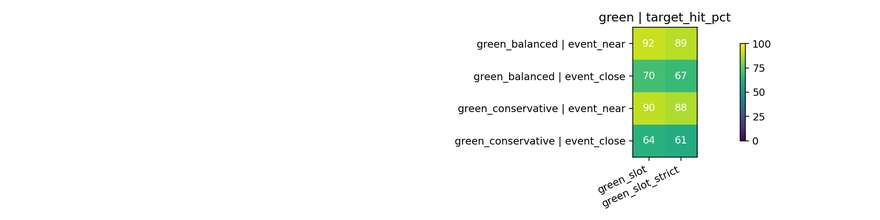

green_cross_color_hit_pct_heatmap.png


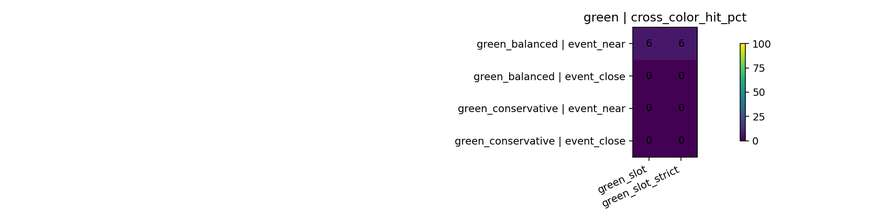

green_stop_sign_negative_hit_pct_heatmap.png


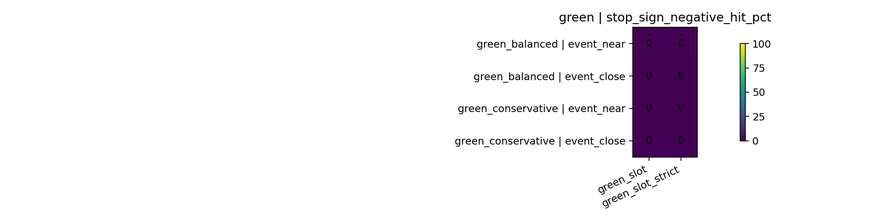

green_final_redline_negative_hit_pct_heatmap.png


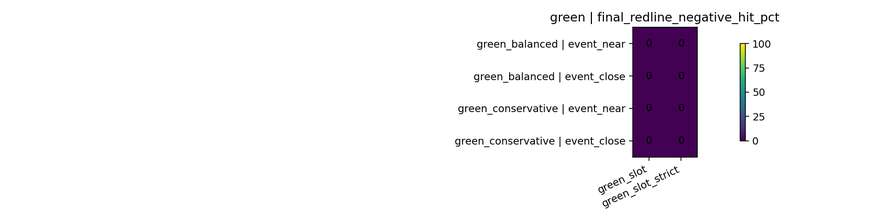

red_target_hit_pct_heatmap.png


red_cross_color_hit_pct_heatmap.png


red_stop_sign_negative_hit_pct_heatmap.png


red_final_redline_negative_hit_pct_heatmap.png


In [9]:
def plot_metric(target, metric):
    sub=summary_df[summary_df.target==target].copy()
    sub['row']=sub['color_profile']+' | '+sub['contour_profile']
    pivot=sub.pivot_table(index='row', columns='roi_profile', values=metric, aggfunc='mean')
    row_order=[]
    for color in [k for k,v in COLOR_PROFILES.items() if v['target']==target]:
        for contour in CONTOUR_PROFILES:
            row_order.append(color+' | '+contour)
    col_order=[k for k,v in ROI_PROFILES.items() if v['target']==target]
    pivot=pivot.reindex(index=row_order, columns=col_order)
    fig,ax=plt.subplots(figsize=(12, max(3,0.55*len(pivot))))
    im=ax.imshow(pivot.values, vmin=0, vmax=100, cmap='viridis')
    ax.set_xticks(np.arange(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=25, ha='right')
    ax.set_yticks(np.arange(len(pivot.index))); ax.set_yticklabels(pivot.index)
    ax.set_title(f'{target} | {metric}')
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val=pivot.values[i,j]
            if np.isfinite(val): ax.text(j,i,f'{val:.0f}',ha='center',va='center',color='white' if val>50 else 'black')
    fig.colorbar(im, ax=ax, shrink=0.75)
    fig.tight_layout()
    out=PLOT_DIR/f'{target}_{metric}_heatmap.png'
    fig.savefig(fs_path(out), dpi=140)
    plt.close(fig)
    return out

paths=[]
for target in ['green','red']:
    for metric in ['target_hit_pct','cross_color_hit_pct','stop_sign_negative_hit_pct','final_redline_negative_hit_pct']:
        paths.append(plot_metric(target, metric))
for p in paths:
    print(p.name)
    show_saved_image(p, width=1000)

## Overlay sheet

대표 후보의 hit/miss/negative false hit을 시각적으로 본다.

특히 red는 다음 질문을 본다.

```text
red_slot_strict_x가 stop sign false hit을 얼마나 줄이나?
red_slot_very_strict는 너무 늦게 잡는가?
final redline은 여전히 traffic red로 잡히는가?
```

In [10]:
def draw_overlay(bgr, row, target):
    out=bgr.copy(); h,w=out.shape[:2]
    # Reference grid: x 0.6/0.7, y 0.35/0.5
    for xnorm in [0.6,0.7]: cv2.line(out,(int(w*xnorm),0),(int(w*xnorm),h),(70,70,70),1)
    for ynorm in [0.35,0.5]: cv2.line(out,(0,int(h*ynorm)),(w,int(h*ynorm)),(70,70,70),1)
    if bool(row.get('hit',False)):
        x=int(row['top_bbox_x']); y=int(row['top_bbox_y']); bw=int(row['top_bbox_w']); bh=int(row['top_bbox_h'])
        color=(0,255,0) if target=='green' else (0,0,255)
        cv2.rectangle(out,(x,y),(x+bw,y+bh),color,3)
        text=f"A={row['top_area_px']:.0f} {bw}x{bh} cx={row['top_center_x_norm']:.2f} cy={row['top_center_y_norm']:.2f}"
        cv2.putText(out,text,(max(2,x-50),max(18,y-8)),cv2.FONT_HERSHEY_SIMPLEX,0.45,color,1,cv2.LINE_AA)
    return out

def make_sheet(detector_name, eval_role, mode, out_path, max_items=8):
    df=frame_df[(frame_df.detector_name==detector_name)&(frame_df.eval_role==eval_role)].copy()
    if len(df)==0: return None
    target=df.target.iloc[0]
    if mode=='hits_smallest':
        df=df[df.hit].sort_values(['top_area_px','top_bbox_h'], ascending=True).head(max_items)
        suffix='hit smallest first'
    elif mode=='hits_largest':
        df=df[df.hit].sort_values(['top_area_px','top_bbox_h'], ascending=False).head(max_items)
        suffix='hit largest first'
    elif mode=='misses':
        df=df[~df.hit].head(max_items); suffix='misses'
    elif mode=='false_hits':
        df=df[df.hit].sort_values(['top_area_px'], ascending=False).head(max_items); suffix='false hits largest first'
    else:
        raise ValueError(mode)
    if len(df)==0: return None
    tile_w,tile_h=432,324
    imgs=[]
    for _,r in df.iterrows():
        bgr=imread_bgr(r.path)
        view=cv2.resize(draw_overlay(bgr,r,target),(tile_w,tile_h),interpolation=cv2.INTER_AREA)
        status='HIT' if bool(r.hit) else 'MISS'
        cv2.putText(view,f'{status} | {r.source_label} | pass={int(r.passed_count)} raw={int(r.raw_contour_count)}',(8,22),cv2.FONT_HERSHEY_SIMPLEX,0.55,(255,255,255),2,cv2.LINE_AA)
        cv2.putText(view,f'{status} | {r.source_label} | pass={int(r.passed_count)} raw={int(r.raw_contour_count)}',(8,22),cv2.FONT_HERSHEY_SIMPLEX,0.55,(0,0,0),1,cv2.LINE_AA)
        cv2.putText(view,r.filename[:70],(8,tile_h-10),cv2.FONT_HERSHEY_SIMPLEX,0.45,(255,255,255),2,cv2.LINE_AA)
        cv2.putText(view,r.filename[:70],(8,tile_h-10),cv2.FONT_HERSHEY_SIMPLEX,0.45,(0,0,0),1,cv2.LINE_AA)
        imgs.append(view)
    header=np.zeros((44,tile_w,3),dtype=np.uint8)
    cv2.putText(header,f'{detector_name} | {eval_role} | {suffix}',(8,30),cv2.FONT_HERSHEY_SIMPLEX,0.50,(255,255,255),1,cv2.LINE_AA)
    sheet=np.vstack([header]+imgs)
    imwrite(out_path,sheet)
    return out_path

SHORTLIST=[
    'green__green_balanced__event_close__green_slot_strict',
    'green__green_balanced__event_near__green_slot_strict',
    'red__red_balanced__event_near__red_slot_strict_x',
    'red__red_balanced__event_close__red_slot_strict_x',
    'red__red_balanced__event_near__red_slot_very_strict',
]

sheet_paths=[]
for det in SHORTLIST:
    for eval_role,modes in {
        'target':['hits_smallest','hits_largest','misses'],
        'cross_color':['false_hits'],
        'stop_sign_negative':['false_hits'],
        'final_redline_negative':['false_hits'],
    }.items():
        for mode in modes:
            p=make_sheet(det,eval_role,mode,OVERLAY_DIR/f'{det}__{eval_role}__{mode}.jpg')
            if p is not None: sheet_paths.append(p)
print('created sheets:',len(sheet_paths))
for p in sheet_paths[:20]: print(p.name)

created sheets: 17
green__green_balanced__event_close__green_slot_strict__target__hits_smallest.jpg
green__green_balanced__event_close__green_slot_strict__target__hits_largest.jpg
green__green_balanced__event_close__green_slot_strict__target__misses.jpg
green__green_balanced__event_near__green_slot_strict__target__hits_smallest.jpg
green__green_balanced__event_near__green_slot_strict__target__hits_largest.jpg
green__green_balanced__event_near__green_slot_strict__target__misses.jpg
green__green_balanced__event_near__green_slot_strict__cross_color__false_hits.jpg
green__green_balanced__event_near__green_slot_strict__stop_sign_negative__false_hits.jpg
red__red_balanced__event_near__red_slot_strict_x__target__hits_smallest.jpg
red__red_balanced__event_near__red_slot_strict_x__target__hits_largest.jpg
red__red_balanced__event_near__red_slot_strict_x__target__misses.jpg
red__red_balanced__event_close__red_slot_strict_x__target__hits_smallest.jpg
red__red_balanced__event_close__red_slot_stric

green__green_balanced__event_close__green_slot_strict__target__hits_smallest.jpg


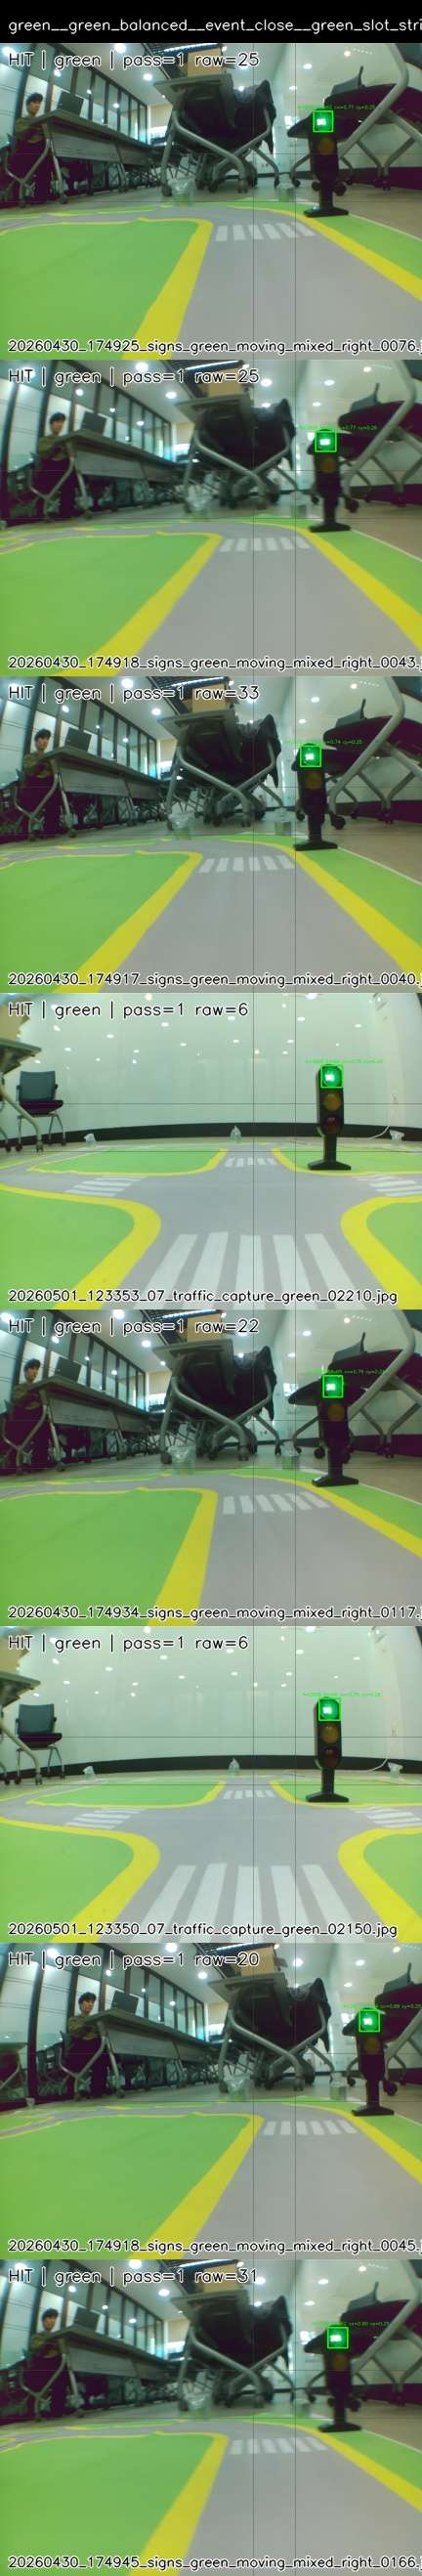

green__green_balanced__event_close__green_slot_strict__target__misses.jpg


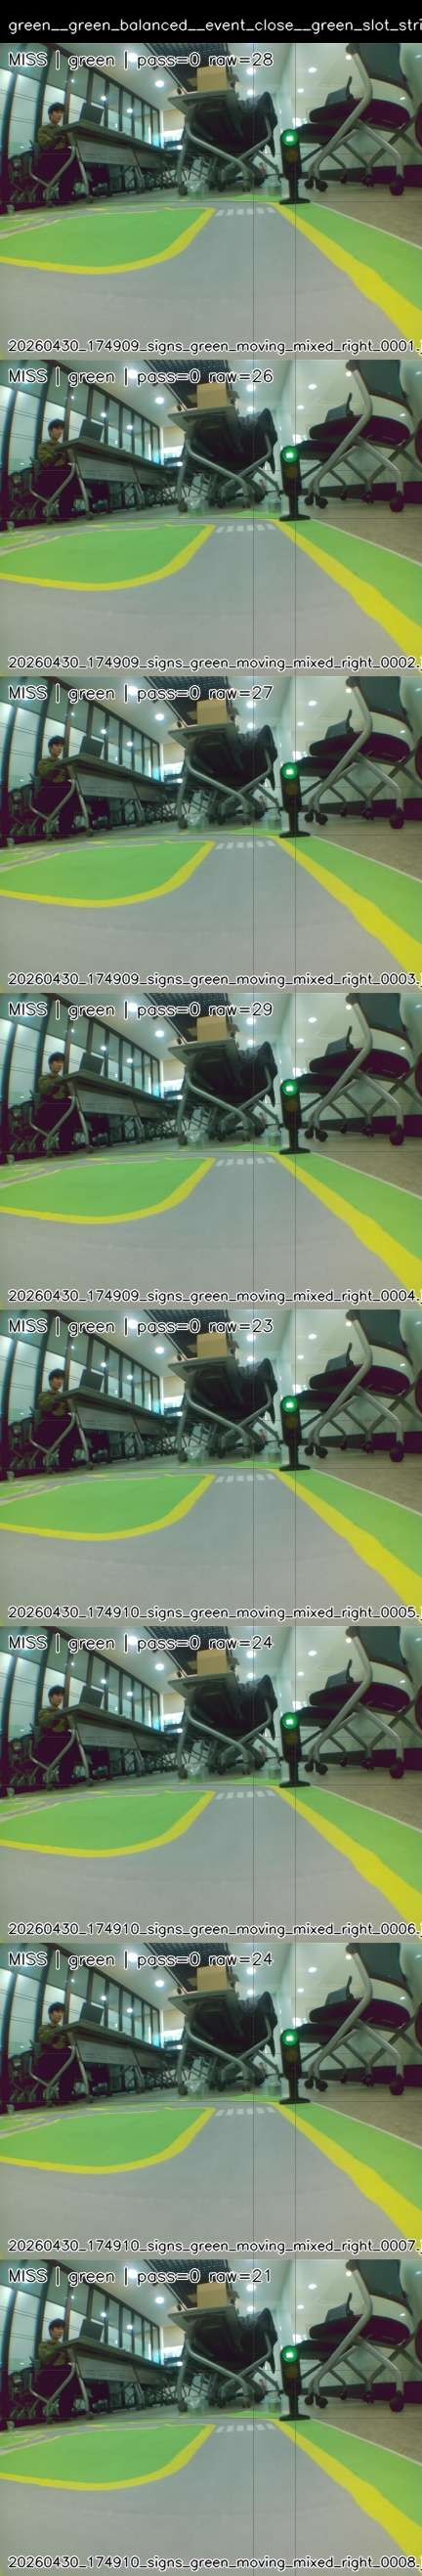

red__red_balanced__event_near__red_slot_strict_x__target__hits_smallest.jpg


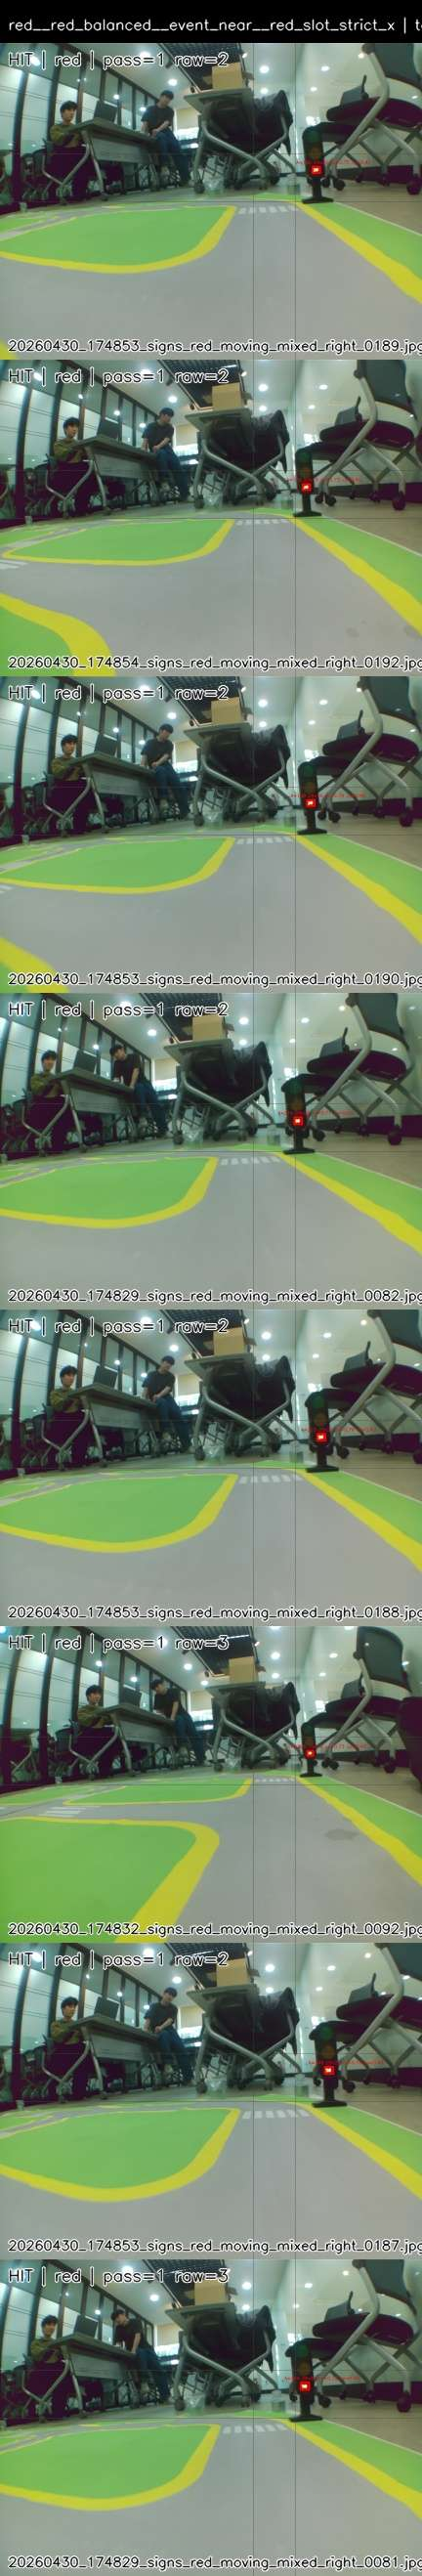

not created or no rows: red__red_balanced__event_near__red_slot_strict_x__stop_sign_negative__false_hits.jpg
not created or no rows: red__red_balanced__event_close__red_slot_strict_x__stop_sign_negative__false_hits.jpg
not created or no rows: red__red_balanced__event_near__red_slot_strict_x__final_redline_negative__false_hits.jpg


In [11]:
DISPLAY_SHEETS=[
    OVERLAY_DIR/'green__green_balanced__event_close__green_slot_strict__target__hits_smallest.jpg',
    OVERLAY_DIR/'green__green_balanced__event_close__green_slot_strict__target__misses.jpg',
    OVERLAY_DIR/'red__red_balanced__event_near__red_slot_strict_x__target__hits_smallest.jpg',
    OVERLAY_DIR/'red__red_balanced__event_near__red_slot_strict_x__stop_sign_negative__false_hits.jpg',
    OVERLAY_DIR/'red__red_balanced__event_close__red_slot_strict_x__stop_sign_negative__false_hits.jpg',
    OVERLAY_DIR/'red__red_balanced__event_near__red_slot_strict_x__final_redline_negative__false_hits.jpg',
]
for p in DISPLAY_SHEETS:
    if exists_fs(p):
        print(p.name)
        show_saved_image(p,width=720)
    else:
        print('not created or no rows:', p.name)

## v2 판단표

마지막 표는 자동 확정이 아니다. 다만 다음 contract 후보를 줄이기 위한 근거이다.

판단 우선순위:

```text
1. final_redline_negative를 낮게 유지
2. green/red cross_color를 낮게 유지
3. stop_sign_negative는 낮으면 좋지만, 최종 runtime에서는 YOLO stop veto/priority를 함께 사용
4. target hit은 event trigger 목적에 맞게 충분하면 됨
```

특히 red traffic event는 단독으로 확정하지 않고, 최종 시스템에서 아래 rule이 필요하다.

```text
if YOLO detects stop sign recently:
    stop_sign_event has priority over traffic_red_event
else:
    traffic_red_event can be accepted from color detector
```

In [12]:
def role(row):
    if row.final_redline_negative_hit_pct > 10: return 'reject_final_redline_conflict'
    if row.cross_color_hit_pct > 2: return 'reject_cross_color'
    if row.target=='green':
        if row.target_hit_pct >= 60: return 'green_contract_candidate'
        return 'too_late_or_strict'
    if row.target=='red':
        if row.target_hit_pct >= 50 and row.stop_sign_negative_hit_pct <= 50: return 'red_candidate_needs_yolo_stop_veto'
        if row.target_hit_pct >= 50: return 'red_candidate_but_stop_veto_required'
        return 'too_late_or_strict'
    return 'review'

judgement_df=summary_df.copy()
judgement_df['judgement']=judgement_df.apply(role,axis=1)
judgement_df=judgement_df.sort_values(['target','final_redline_negative_hit_pct','cross_color_hit_pct','stop_sign_negative_hit_pct','target_hit_pct'], ascending=[True,True,True,True,False])
judgement_df.to_csv(TABLE_DIR/'traffic_event_v2_candidate_judgement.csv', index=False, encoding='utf-8-sig')
for target in ['green','red']:
    print('\n====',target,'judgement ====')
    display(judgement_df[judgement_df.target==target][['detector_name','judgement','target_hit_pct','cross_color_hit_pct','stop_sign_negative_hit_pct','final_redline_negative_hit_pct','target_top_area_px_median','target_top_bbox_h_median','target_top_center_x_norm_median','target_top_center_y_norm_median']])


==== green judgement ====


,detector_name,judgement,target_hit_pct,cross_color_hit_pct,stop_sign_negative_hit_pct,final_redline_negative_hit_pct,target_top_area_px_median,target_top_bbox_h_median,target_top_center_x_norm_median,target_top_center_y_norm_median
6,green__green_conservative__event_near__green_slot,green_contract_candidate,90.415335,0.000000,0.000000,0.0,3864.0,77.0,0.769676,0.223765
7,green__green_conservative__event_near__green_s...,green_contract_candidate,87.859425,0.000000,0.000000,0.0,3840.5,77.0,0.775077,0.224794
0,green__green_balanced__event_close__green_slot,green_contract_candidate,69.968051,0.000000,0.000000,0.0,4822.5,84.0,0.786265,0.215021
1,green__green_balanced__event_close__green_slot...,green_contract_candidate,67.412141,0.000000,0.000000,0.0,4803.0,84.0,0.788580,0.215021
4,green__green_conservative__event_close__green_...,green_contract_candidate,63.578275,0.000000,0.000000,0.0,4522.0,85.0,0.785880,0.209362
5,green__green_conservative__event_close__green_...,green_contract_candidate,61.341853,0.000000,0.000000,0.0,4520.5,84.5,0.788194,0.209877
2,green__green_balanced__event_near__green_slot,reject_cross_color,91.693291,6.413994,0.429185,0.0,4314.5,79.0,0.771991,0.224794
3,green__green_balanced__event_near__green_slot_...,reject_cross_color,89.137380,6.413994,0.429185,0.0,4270.0,79.0,0.777006,0.225309



==== red judgement ====


,detector_name,judgement,target_hit_pct,cross_color_hit_pct,stop_sign_negative_hit_pct,final_redline_negative_hit_pct,target_top_area_px_median,target_top_bbox_h_median,target_top_center_x_norm_median,target_top_center_y_norm_median
12,red__red_balanced__event_near__red_slot_strict_x,red_candidate_needs_yolo_stop_veto,63.556851,0.0,0.000000,0.0,1222.50,42.0,0.764275,0.404835
18,red__red_conservative__event_near__red_slot_st...,red_candidate_needs_yolo_stop_veto,54.227405,0.0,0.000000,0.0,540.25,35.0,0.769676,0.406893
9,red__red_balanced__event_close__red_slot_strict_x,red_candidate_needs_yolo_stop_veto,51.603499,0.0,0.000000,0.0,1347.50,45.0,0.770062,0.405350
13,red__red_balanced__event_near__red_slot_very_s...,red_candidate_needs_yolo_stop_veto,50.437318,0.0,0.000000,0.0,1276.00,45.0,0.778549,0.405350
19,red__red_conservative__event_near__red_slot_ve...,too_late_or_strict,46.355685,0.0,0.000000,0.0,563.00,35.0,0.778549,0.406893
10,red__red_balanced__event_close__red_slot_very_...,too_late_or_strict,44.897959,0.0,0.000000,0.0,1399.75,46.0,0.778356,0.405350
14,red__red_conservative__event_close__red_slot,too_late_or_strict,26.530612,0.0,0.000000,0.0,1748.00,49.0,0.774691,0.405864
15,red__red_conservative__event_close__red_slot_s...,too_late_or_strict,23.323615,0.0,0.000000,0.0,1820.75,50.5,0.783951,0.406893
16,red__red_conservative__event_close__red_slot_v...,too_late_or_strict,20.699708,0.0,0.000000,0.0,1820.00,50.0,0.788966,0.408951
8,red__red_balanced__event_close__red_slot,red_candidate_needs_yolo_stop_veto,57.725948,0.0,2.575107,0.0,1347.00,45.0,0.764082,0.404835


## v2 이후 다음 판단

이 노트북을 실행한 뒤 봐야 할 것은 다음이다.

1. Green은 `green_balanced + event_close + green_slot_strict`가 너무 늦지 않은가?
2. Red는 `red_slot_strict_x`나 `red_slot_very_strict`가 stop sign false hit을 충분히 줄이는가?
3. Red target miss가 실제로는 아직 멀어서 괜찮은 miss인가, 아니면 가까운데 놓친 miss인가?
4. Final redline이 traffic red로 잡히는 후보가 있는가?
5. Runtime에서 YOLO stop veto를 넣으면 남은 red-stop 혼동이 허용 가능한가?

최종 contract는 이 판단 후 별도 셀/노트북에서 만든다. 현재 단계에서는 후보의 성격을 명확히 하는 것이 목표이다.